In [1]:
# import argparse

# def str_to_bool(value):
#     """Convert argument string to boolean."""
#     if isinstance(value, bool):
#         return value
#     if value.lower() in ('true', '1', 'yes', 'y'):
#         return True
#     elif value.lower() in ('false', '0', 'no', 'n'):
#         return False
#     else:
#         raise argparse.ArgumentTypeError("Boolean value expected (true/false or 1/0).")
        
# def int_or_str(val):
#     try:
#         return int(val)
#     except ValueError:
#         return val

# parser = argparse.ArgumentParser()
# parser.add_argument("--index", type=int_or_str, required=True, help="Filename index")
# parser.add_argument("--retrain", type=str_to_bool, required = False, default = True)
# parser.add_argument("--subset_size", type=float, required=True)
# parser.add_argument("--noadv", type=str_to_bool, required=True)

# parser.add_argument("--max_epochs", type=int, required=True)

# parser.add_argument("--KL_scaling", type=float, required=True)
# parser.add_argument("--n_cat_discriminator_train", type=int, required=True)
# parser.add_argument("--n_pert_discriminator_train", type = int, required = True)
# parser.add_argument("--n_adversarial_start", type = int, required = True)

# parser.add_argument("--cat_dropout", type=float, required=True)
# parser.add_argument("--pert_dropout", type=float, required=True)

# parser.add_argument("--generator_dropout_rate", type=float, required=True)
# parser.add_argument("--n_layers_vae", type=int, required=True)
# parser.add_argument("--pert_n_layers", type = int, default = 4)

# parser.add_argument("--main_max_lr", type=float, required=True)
# parser.add_argument("--gen_max_lr", type=float, required=True)
# parser.add_argument("--cat_max_lr", type=float, required=True)
# parser.add_argument("--pert_max_lr", type=float, required=True)


# parser.add_argument("--cat_max_penalty_weight", type=float, required=True)
# parser.add_argument("--cat_bias_pert_scaler", type=float, required=True)
# parser.add_argument("--cat_pert_method", type=str, default = 'orthogonality')
# parser.add_argument("--cat_pert_pert_label", type=str_to_bool, default=False)
# parser.add_argument("--cat_bias_lambda_L2", type=float, required=True)

# parser.add_argument("--spectral_loss_factor", type=float, required=True)
# parser.add_argument("--uniform_lambda_L2", type=float, required=True)

# parser.add_argument("--contrastive_loss_scaler", type=float, required=True)
# parser.add_argument("--contrastive_loss_type", type = str, required=True)


# ########################################################################
# args = parser.parse_args()
# fn = str(args.index)

# retrain = args.retrain
# subset_size = args.subset_size
# no_adv = args.noadv
# vae_scaling_KL = args.KL_scaling
# max_epochs = args.max_epochs
# n_cat_discriminator_train = args.n_cat_discriminator_train
# n_pert_discriminator_train = args.n_pert_discriminator_train
# n_adversarial_start = args.n_adversarial_start
# # pert_spectral_norm = args.pert_spectral_norm
# # cat_spectral_norm = args.cat_spectral_norm

# main_max_lr = args.main_max_lr
# gen_max_lr = args.gen_max_lr
# cat_max_lr = args.cat_max_lr
# pert_max_lr = args.pert_max_lr

# cat_dropout = args.cat_dropout
# pert_dropout = args.pert_dropout

# generator_dropout_rate = args.generator_dropout_rate
# n_layers_vae = args.n_layers_vae
# pert_n_layers = args.pert_n_layers


# cat_max_penalty_weight = args.cat_max_penalty_weight
# cat_bias_pert_scaler = args.cat_bias_pert_scaler
# cat_pert_method = args.cat_pert_method
# cat_pert_pert_label = args.cat_pert_pert_label
# cat_bias_lambda_L2 = args.cat_bias_lambda_L2 

# spectral_loss_factor = args.spectral_loss_factor
# uniform_lambda_L2 = args.uniform_lambda_L2

# contrastive_loss_scaler = args.contrastive_loss_scaler
# contrastive_loss_type = args.contrastive_loss_type


# #python test_run.py --index 46 --retrain true --subset_size 0.15 --noadv false --max_epochs 600 --KL_scaling 5e-3 --n_cat_discriminator_train 5 --n_pert_discriminator_train 5 --cat_dropout 0.1 --pert_dropout 0.1 --n_adversarial_start 200 --main_max_lr 2e-3 --gen_max_lr 2.75e-4 --cat_max_lr 1e-3 --pert_max_lr 1e-3 --cat_max_penalty_weight 11 --generator_dropout_rate 0.7 --n_layers_vae 3 --pert_n_layers 4 --cat_bias_pert_scaler 0 --cat_pert_method orthogonality --cat_pert_pert_label false --cat_bias_lambda_L2 1e-3 --spectral_loss_factor 0 --uniform_lambda_L2 0 --contrastive_loss_scaler 0 --contrastive_loss_type bulk_actual


In [2]:
index = 'dev'
subset_size = 0.15
noadv = False
max_epochs = 30
vae_scaling_KL = 5e-3
n_cat_discriminator_train = 5
n_pert_discriminator_train = 5
cat_dropout = 0.1
pert_dropout = 0.1
n_adversarial_start = 0
main_max_lr = 2e-3
gen_max_lr = 2.75e-4
cat_max_lr = 1e-3
pert_max_lr = 1e-3
cat_max_penalty_weight = 11
generator_dropout_rate = 0.7
n_layers_vae = 3
cat_bias_pert_scaler = 0
cat_pert_method = 'orthogonality'
cat_bias_lambda_L2 = 1e-2
spectral_loss_factor = 0
uniform_lambda_L2 = 0
pert_n_layers = 4
cat_pert_pert_label = False


In [3]:
import os
import time
import math

from tqdm import tqdm

import pandas as pd
import numpy as np
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import sys
sclembas = '/home/hmbaghda/Projects/scLEMBAS'
sys.path.insert(1, os.path.join(sclembas))
from scLEMBAS import io
from scLEMBAS import preprocess as pp 
from scLEMBAS.model.train import TrainSC
from scLEMBAS.model.scl import SignalingModel

import Tahoe_utils as Tu

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/nobackup/


[KeOps] Warning : There were warnings or errors :
<stdin>:1:10: fatal error: cuda.h: No such file or directory
compilation terminated.

[KeOps] Warning : 
    The location of Cuda header files cuda.h and nvrtc.h could not be detected on your system.
    You must determine their location and then define the environment variable CUDA_PATH,
    either before launching Python or using os.environ before importing keops. For example
    if these files are in /vol/cuda/10.2.89-cudnn7.6.4.38/include you can do :
      import os
      os.environ['CUDA_PATH'] = '/vol/cuda/10.2.89-cudnn7.6.4.38'
    
[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/keopscore/binders/nvrtc/nvrtc_jit.cpp:16:10: fatal error: cuda.h: No such file or directory
 #include <cuda.h>
          ^~~~~~~~
compilation terminated.

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] W

/nobackup/users/hmbaghda/Software/miniforge3/envs/scLEMBAS/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
subset = True

In [5]:
n_cores = 30
os.environ["OMP_NUM_THREADS"] = str(n_cores)
os.environ["MKL_NUM_THREADS"] = str(n_cores)
os.environ["OPENBLAS_NUM_THREADS"] = str(n_cores)
os.environ["VECLIB_MAXIMUM_THREADS"] = str(n_cores)
os.environ["NUMEXPR_NUM_THREADS"] = str(n_cores)

seed = 888
mod_seed = 888
data_path = '/nobackup/users/hmbaghda/scLEMBAS/analysis'
author = 'Tahoe100M'

device = "cuda" if torch.cuda.is_available() else "cpu"



Load data:

In [6]:
sn_ppis = pd.read_csv(os.path.join(data_path, 'processed', author + '_sn_ppis.csv'), 
                     index_col = 0)
source_label = 'source_genesymbol'
target_label = 'target_genesymbol'
weight_label = 'mode_of_action'
stimulation_label = 'consensus_stimulation'
inhibition_label = 'consensus_inhibition'

tf_adata = io.read_tfad(os.path.join(data_path, 'processed', author + '_consensus_tf_activity.h5ad'))
adata = sc.read_h5ad(os.path.join(data_path, 'processed', author + '_expr_in.h5ad'))
expr = adata.to_df().copy()

# basic formatting checks
if not np.all(tf_adata.var_names == sorted(tf_adata.var_names)):
    raise ValueError('Ensure TF adata features are sorted on input')
    
if not np.all(adata.obs_names == tf_adata.obs_names):
    raise ValueError('Ensure gene expression and TF activity sample features are orderd the same')
    
if len(set(tf_adata.obs.drug)) != len(tf_adata.obs.drug.cat.categories):
    raise ValueError('Make sure only present perturbations are in the categorical columns')
    
if len(set(tf_adata.obs.cell_line)) != len(tf_adata.obs.cell_line.cat.categories):
    raise ValueError('Make sure only present cell lines are in the categorical columns')

# Train/test split:

In [7]:
train_split, test_split = Tu.Tahoe100M_split(tf_adata,
                                          train_frac = 0.9, 
                                          min_drug_frac = 0.7, 
                                          min_cell_line_frac = 0.7, 
                                          exclude_control = True, 
                                          max_attempts = 1000, 
                                          seed = seed)

train_cells = train_split['barcodes']
test_cells = test_split['barcodes']

cell_line_counts = pd.DataFrame({
    'train': train_split['cell_line_counts'],
    'test': test_split['cell_line_counts']
}).sort_values(by = 'train', ascending = True)

drug_counts = pd.DataFrame({
    'train': train_split['drug_counts'],
    'test': test_split['drug_counts']
}).sort_values(by = 'train', ascending = True)



In [8]:
cell_line_counts

,train,test
cell_line,,
CVCL_0371,23,6
CVCL_0546,24,5
CVCL_1056,24,5
CVCL_0480,26,3
CVCL_1550,26,3
CVCL_0459,27,2
CVCL_1285,27,2
CVCL_0023,28,1
CVCL_0399,28,1


In [9]:
drug_counts

,train,test
drug,,
Neratinib (maleate),8,2
Almonertinib (mesylate),8,2
Tofacitinib (citrate),8,2
Rucaparib (phosphate),8,2
Retinoic acid,8,2
Rapamycin,8,2
Norepinephrine (hydrochloride),8,2
Filgotinib,8,2
Tofacitinib,9,1


Get the PLS models for test prediction projections -- we assume at most the # of components needed to describe the subset is that of the full dataset, so we set that as the number of components, rather than doing the automated elbow selection.

In [10]:
# from scLEMBAS import latent_separation as ls
# import joblib

# ctrl_pert = 'DMSO_TF'
# pls_rank = tf_adata.uns['pls']['model_fit']['n_components']
# pls_models = {}

# pls_fn = os.path.join(
#     data_path, 'trash',
#     '_'.join([author, 'PLSfits', 'seed{}'.format(seed)]) + '.pkl'
# )

# if not os.path.isfile(pls_fn):
#     print('Get PLS model fits')
#     for test_cond in tqdm(tf_adata[test_cells, :].obs.condition.unique()):
#         cell_line, pert = test_cond.split('^')
#         tf_adata_sub, r2_df = ls.pls_da_pipeline(
#             adata = tf_adata, 
#             pert_ids = [pert, ctrl_pert],
#             cat_ids = cell_line,
#             n_components = pls_rank, 
#             pert_col = 'drug', 
#             cat_col = 'cell_line', 
#             separate_by = 'perturbation', 
#             control_confounders = [], 
#             covariate_associations = ['drug'],
#             scale = False, # TF activity already Z-scored
#             run_umap = False, 
#             file_prefix = None, 
#             verbose = True,
#             seed = seed, 
#             n_cores = n_cores
#         )

#         for k in ['pls_mod']: # ['encoder_y', '']:
#             pls_models[test_cond] = {
#                 k: tf_adata_sub.uns['pls'][k]
#             }
# #         pls_models[test_cond]['umap_pls_mod'] = tf_adata_sub.uns['umap_pls']['umap_pls_mod']
#         pls_models[test_cond]['top_components_drug'] = ls.get_top_components(r2_df, top_components_cov = 'drug')

#     joblib.dump(pls_models, pls_fn)
#     del tf_adata_sub

In [11]:
if subset:
    train_cells = []
    np.random.seed(seed)
    for cond in train_split['conditions'].condition:
        subset_cond = tf_adata.obs[tf_adata.obs.condition == cond]
        subset_cells = list(np.random.choice(
            subset_cond.index,
            size = int(np.round(subset_cond.shape[0] * subset_size)),
            replace = False
        ))
        train_cells+=subset_cells
    tf_adata = tf_adata[tf_adata.obs_names.isin(train_cells + test_cells),:].copy()
    adata = adata[tf_adata.obs_names, :].copy()
    expr = adata.to_df().copy()

In [12]:
cat_col = 'cell_line'
pert_col = 'drug'

In [13]:
tf_adata[train_cells, :].obs[cat_col].value_counts().unique()

array([8820, 8505, 8190, 7560, 7245])

In [14]:
tf_adata[train_cells, :].obs[pert_col].value_counts().unique()

array([3150, 2835, 2520])

**Note: As mentioned in Notebook 00A, when splitting the data into train-test splits, conditions will remain balanced, but drug/cell lines will not be completely balanced (due to OOD, cannot ensure the drug and cell line split is the same as the condition split).** 

# Hyper-parameters:

In [15]:
def generate_lr_params(n_epochs, 
                       max_lr, 
                       lr_scaling_factor=10, 
                       lr_decay=0.75,
                       n_restarts=4,
#                        n_cat_discriminator_train=5,
#                        n_pert_discriminator_train=5,
                       n_adversarial_start=0,
                       role='scl'):
    """
    Generate LR scheduler params for WarmupCosineAnnealingWarmRestarts
    that ensures discriminator and generator follow the same curve in real (epoch) time.

    For 'generator', it updates when either discriminator is active.

    Returns:
        Dict of scheduler parameters
    """

    total_active_epochs = n_epochs
    n_steps = n_epochs  # default for SCL

    if role in ['generator', 'cat_discriminator', 'pert_discriminator']:
        if n_adversarial_start >= n_epochs: # won't be used anyways
            n_adversarial_start = 0
        total_active_epochs = n_epochs - n_adversarial_start
        n_steps = total_active_epochs // 1

#    DEPRECATED: this was necessary when generator trained every n_discriminator_train epochs
#                rather than discriminator training n_discriminator_train times every epoch
#     elif role in 'generator':
#         # Generator steps on any epoch divisible by either cat or pert discriminator schedule
#         effective_epochs = range(n_adversarial_start, n_epochs)
#         n_steps = sum(
#             (e % n_cat_discriminator_train == 0) or (e % n_pert_discriminator_train == 0)
#             for e in effective_epochs
#         )

    T_0 = max(1, n_steps // n_restarts)
    warmup_epochs = max(1, n_steps // 10)

    if warmup_epochs >= T_0:
        warmup_epochs = 0

    return {
        'max_epochs': n_epochs,
        'maximum_learning_rate': max_lr,
        'minimum_learning_rate': max_lr / lr_scaling_factor,
        'lr_restart_epoch': T_0,
        'n_optimizer_resets': 0,
        'lr_decay': lr_decay,
        'lr_restart_factor': 1,
        'warmup_epochs': warmup_epochs
    }


In [16]:
projection_amplitude_in = 10
projection_amplitude_out = 1

bionet_params = {'target_steps': 100, 
                 'max_steps': 120, 
                 'exp_factor': 50, 
                 'tolerance': 1e-5, 
                 'leak': 1e-2}

spectral_radius_params = {'n_probes_spectral': 5, 
                          'power_steps_spectral': 5, 
                          'subset_n_spectral': 5, 
                         'track_spectral_radius': True}
target_spectral_radius = 0.9

noise_params = {
    'network_noise_scale': 0.01, 
    'min_network_noise': 0.0015, #0.0025, 
    'gradient_noise_scale': 1e-9, 
    'include_gradient_noise_vae': True, 
    'include_gradient_noise_embedding': True, 
    'constant_gradient_noise': True
    
}


In [17]:
loss_scaler = 100
prediction_loss_fn = torch.nn.MSELoss(reduction='mean')


batch_params = {
    'train_batch_size': int(512*8), 
    'test_batch_size': int(512*8), 
    'validation_batch_size': np.nan
}


max_batch_scaler = 24

if subset:
    if subset_size < 0.02:
        batch_scaler = 2
    else:
        batch_scaler = int(8 * round(math.ceil(subset_size / 0.05) * 0.05, 2) / 0.05)
        batch_scaler = min(batch_scaler, max_batch_scaler)

    batch_params['train_batch_size'] = int(512*batch_scaler)
    batch_params['test_batch_size'] = int(512*batch_scaler)
# max_epochs = 600

lr_scaling_factor = 10
lr_decay = 0.9
n_restarts = 4
lr_params = generate_lr_params(n_epochs = max_epochs, 
                               max_lr = main_max_lr, 
                               lr_scaling_factor = lr_scaling_factor, 
                               lr_decay = lr_decay,
                               n_restarts = n_restarts,
                               n_adversarial_start = np.nan, 
#                                n_cat_discriminator_train = np.nan, 
#                                n_pert_discriminator_train = np.nan,
                               role = 'scl')

# reset_state = False # DEPRECATED
# initialize_fc = True # DEPRECATED

In [18]:
bionet_params['cat_max_norm'] = 100
regularization_params = {
    'input_lambda_L2': 0, # irrelevant because setting the requires grad to False
    
    'bn_weights_lambda_L2': 1e-7,
    'moa_lambda_L1': 1e2,
    'uniform_lambda_L2': uniform_lambda_L2, #0, #1e-7, 
    'uniform_min': -1/projection_amplitude_out,
    'uniform_max': 1/projection_amplitude_out,
    'adj_scaling_KL': 0,  # using uniform/bn_weights already
    'adj_prior_mu': 0, # irrelevant because adj_scaling_KL is 0
    'adj_prior_sigma': 0.2, # irrelevant because adj_scaling_KL is 0
    
    'output_weights_lambda_L2': 1e-7,
    'output_bias_lambda_L2': 1e-7,
    
    'spectral_loss_factor': spectral_loss_factor,
    
    
    'global_bias_lambda_L2': 0, # using KL divergence instead
    'global_bias_lambda_L1': 0, # using KL divergence instead
    'cat_bias_lambda_L2': cat_bias_lambda_L2, # 1e-4, # allow for generalization (not collapsing on perturbation)
    'cat_bias_lambda_L1': 0, # using cat max norm
}

contrastive_loss_params = {
    'methods': [], 
    'lambda_scalers': [], 
    'understimate_only': True, # only for _bulk_actual
    'min_percentile': 0.3, # only for _sc_actual
    'triplet_margin_frac': 0.1,
}

cat_pert_params = {'regularization_scaler': cat_bias_pert_scaler, 
                       'method': cat_pert_method, 
                       'per_label': cat_pert_pert_label, 
                       'include_adjacency': False, 
                       'temperature': 0.1
                      }



In [19]:
training_params = {
    **lr_params, 
    **batch_params, 
    **regularization_params, 
    **spectral_radius_params,
    **noise_params
}

training_params['prediction_loss_fn_scaler'] = loss_scaler

VAE:

In [20]:
# building
# n_layers_vae = 1
n_nodes = len(set(sn_ppis[source_label].tolist() + sn_ppis[target_label].tolist()))
vae_n_hidden_nodes = list(np.round(np.linspace(adata.shape[1], n_nodes, n_layers_vae + 2)).astype(int)[1:-1])

# generator_dropout_rate = 0.7
vae_mod_params = {
    'vae_batch_momentum': 0.01, 
    'vae_layer_norm': False, 
    'vae_dropout_rate': generator_dropout_rate,
    'vae_activation_fn': nn.LeakyReLU,
    'vae_n_hidden_nodes': vae_n_hidden_nodes, 
    'vae_var_min': 1e-4

} 
bionet_params = {**bionet_params, **vae_mod_params}

# training
vae_params = {
    'prior_mu': 0, 
    'prior_sigma': 1,
    'scaling_KL': vae_scaling_KL, #1e-2, 
    'lambda_l2': 1e-5, 
    'optimizer': torch.optim.Adam
}

 
n_restarts_adversarial = 4
vae_lr_params = generate_lr_params(n_epochs = max_epochs,
                                   max_lr = gen_max_lr, #max_lr,
                                   lr_scaling_factor = lr_scaling_factor, 
                                   lr_decay = lr_decay,
                                   n_restarts = n_restarts_adversarial,
                                   n_adversarial_start = n_adversarial_start,
#                                n_cat_discriminator_train = n_cat_discriminator_train, 
#                                n_pert_discriminator_train = n_pert_discriminator_train,
                                   role = 'generator')
vae_params = {**vae_params, **vae_lr_params}
del vae_params['max_epochs']


Discriminator:

In [21]:
discriminator_params = {
    'batch_momentum': None,
    'layer_norm': False,
    'spectral_norm': np.nan, #False,
    'dropout_rate': np.nan,
    'activation_fn': nn.LeakyReLU,
    'n_hidden_nodes': np.nan,
    'lr_restart_factor': 1,
    'optimizer': torch.optim.Adam,
    'discriminator_lambda_L2': 1e-3,
    'discriminator_penalty_weight': np.nan, 
    'bionet_activation': False,
    'smooth_labels': True, 
    'epsilon_smooth': np.nan
}

In [22]:
# architecture -- pert >> cat bc harder classification problem
cat_n_layers_disc = 3
cat_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                    cell_line_counts.shape[0],
                                                    cat_n_layers_disc + 2)).astype(int)[1:-1])
cat_discriminator_params = discriminator_params.copy()
cat_discriminator_params['n_hidden_nodes'] = cat_disc_n_hidden_nodes
cat_discriminator_params['dropout_rate'] = cat_dropout

cat_spectral_norm = True
cat_discriminator_params['spectral_norm'] = cat_spectral_norm
if cat_spectral_norm:
    cat_discriminator_params['discriminator_lambda_L2'] = 0


pert_n_layers_disc = pert_n_layers
pert_disc_n_hidden_nodes = list(np.round(np.linspace(n_nodes, 
                                                     drug_counts.shape[0], 
                                                     pert_n_layers_disc + 2)).astype(int)[1:-1])

# add 3 additional "starting" layers since classifying perturbation is difficult
pert_disc_n_hidden_nodes = [pert_disc_n_hidden_nodes[0]]*3 + pert_disc_n_hidden_nodes

pert_discriminator_params = discriminator_params.copy()
pert_discriminator_params['n_hidden_nodes'] = pert_disc_n_hidden_nodes
pert_discriminator_params['dropout_rate'] = 0.1

pert_spectral_norm = True
pert_discriminator_params['spectral_norm'] = pert_spectral_norm
if pert_spectral_norm:
    pert_discriminator_params['discriminator_lambda_L2'] = 0

cat_discriminator_params['epsilon_smooth'] = 1/tf_adata.obs.cell_line.nunique()
pert_discriminator_params['epsilon_smooth'] = 1/tf_adata.obs.drug.nunique()


In [23]:
# adverserial penalty curve
# cat_max_penalty_weight = 11
cat_b_adv = 2.5
pert_max_penalty_weight = 10 #15
pert_b_adv = 2 #10

if n_adversarial_start < max_epochs:
    cat_discriminator_params['discriminator_penalty_weight'] = pp.discriminator_weight_curve(
        n_epochs = max_epochs - n_adversarial_start,
        min_penalty_weight = 0.01,
        max_penalty_weight = cat_max_penalty_weight,
        a = 1,
        b = cat_b_adv, 
        curve_type = 'power')

    n_pert_train = int(max_epochs/2)
    pert_discriminator_penalty_weight = [0] * n_pert_train
    pert_discriminator_penalty_weight += pp.discriminator_weight_curve(
        n_epochs = max_epochs - n_pert_train - n_adversarial_start,
        min_penalty_weight = 1e-5,
        max_penalty_weight = pert_max_penalty_weight,
        a = 1,
        b = pert_b_adv, 
        curve_type = 'power')
    pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight
else:
    cat_discriminator_params['discriminator_penalty_weight'] = [0]*max_epochs
    pert_discriminator_params['discriminator_penalty_weight'] = [0]*max_epochs




# # DEPRECATED: when n_discriminator_train trained generator less frequently instead of disc more frequently
# def expand_elements(lst, n_discriminator_train):
#     return [x for x in lst for _ in range(n_discriminator_train)]
# n_adj = 1 if n_cat_discriminator_train > 1 else 0
# cat_discriminator_penalty_weight = pp.discriminator_weight_curve(
#     n_epochs = int((max_epochs - n_adversarial_start)/n_cat_discriminator_train) - n_adj,
#     min_penalty_weight = 0.1,
#     max_penalty_weight = cat_max_penalty_weight,
#     a = 1,
#     b = cat_b_adv, 
#     curve_type = 'power')
# cat_discriminator_penalty_weight = expand_elements(cat_discriminator_penalty_weight, n_cat_discriminator_train)
# cat_discriminator_penalty_weight = [0]*n_adj*n_cat_discriminator_train + cat_discriminator_penalty_weight
# cat_discriminator_params['discriminator_penalty_weight'] = cat_discriminator_penalty_weight

# n_pert_train = 300
# pert_discriminator_penalty_weight = [0] * n_pert_train

# n_adj = n_pert_discriminator_train if n_pert_discriminator_train > 1 and n_pert_train == 0 else 0
# pdpw2 = pp.discriminator_weight_curve(
#     n_epochs = int((max_epochs - n_pert_train - n_adversarial_start)/n_pert_discriminator_train) - n_adj,
#     min_penalty_weight = 1e-5,
#     max_penalty_weight = pert_max_penalty_weight,
#     a = 1,
#     b = pert_b_adv, 
#     curve_type = 'power')
# pdpw2 = expand_elements(pdpw2, n_pert_discriminator_train)
# pert_discriminator_penalty_weight += [0]*n_adj*n_pert_discriminator_train + pdpw2


# pert_discriminator_params['discriminator_penalty_weight'] = pert_discriminator_penalty_weight

In [24]:
# discriminator LRs

# categorical
discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = cat_max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
#     n_pert_discriminator_train = np.nan,
#     n_cat_discriminator_train = n_cat_discriminator_train,
    role = 'cat_discriminator')
del discriminator_lr_params['max_epochs']

cat_discriminator_params = {**cat_discriminator_params, **discriminator_lr_params}

# perturbation
discriminator_lr_params = generate_lr_params(
    n_epochs = max_epochs,
    max_lr = pert_max_lr,
    lr_scaling_factor = lr_scaling_factor, 
    lr_decay = lr_decay,
    n_restarts = n_restarts_adversarial,
    n_adversarial_start = n_adversarial_start, 
#     n_pert_discriminator_train = n_pert_discriminator_train,
#     n_cat_discriminator_train = np.nan,
    role = 'pert_discriminator')
del discriminator_lr_params['max_epochs']

pert_discriminator_params = {**pert_discriminator_params, **discriminator_lr_params}


Visualize hyperparameters:

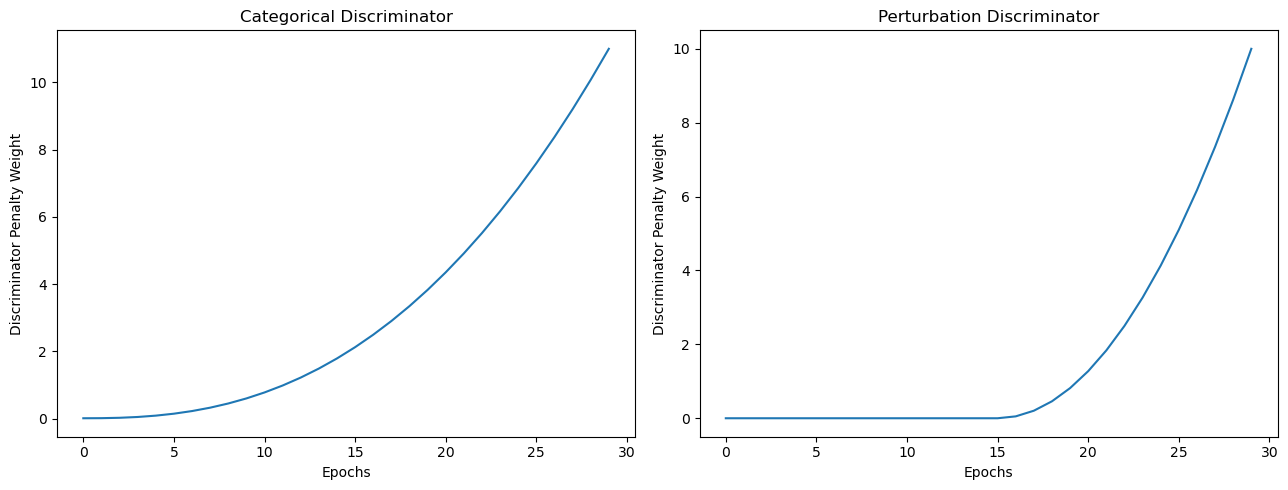

In [25]:
fig, ax = plt.subplots(ncols = 2, figsize = (13,5))
sns.lineplot(cat_discriminator_params['discriminator_penalty_weight'], ax = ax[0])
ax[0].set_title('Categorical Discriminator')

sns.lineplot(pert_discriminator_params['discriminator_penalty_weight'], ax = ax[1])
ax[1].set_title('Perturbation Discriminator')

for i in range(2):
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Discriminator Penalty Weight')
    
fig.tight_layout();

# Build model and trainer

In [26]:
# input stimulation
X_in = pd.get_dummies(tf_adata.obs.drug).astype(int)
X_in.drop(columns = 'DMSO_TF', inplace = True) # all 0s

In [27]:
mod = SignalingModel(
    net = sn_ppis,
    X_in = X_in,
    y_out = tf_adata.to_df().copy(), 
    expr = expr, 
    covariates = tf_adata.obs.copy(),
    categorical_covariate_keys = ['cell_line'],
    projection_amplitude_in = projection_amplitude_in, 
    projection_amplitude_out = projection_amplitude_out,
    weight_label = weight_label, source_label = source_label, target_label = target_label,
    bionet_params = bionet_params, 
    dtype = torch.float32, device = device, seed = mod_seed)

mod.input_layer.weights.requires_grad = False # don't learn scaling factors for the ligand input concentrations
mod.signaling_network.prescale_weights(target_radius = target_spectral_radius) # spectral radius


In [28]:
contrastive_loss_params = {
    'methods': ['sc_actual', 'sc_actual_control'],#, 'sc_predicted', 'sc_triplet', 'bulk_actual', 'bulk_predicted', 'bulk_triplet'], 
    'lambda_scalers': [0.5, 0.5],#, 1,1,1,1,1], 
    'understimate_only': None, # only for _bulk_actual
    'min_percentile': 0.99, # only for _sc_actual
    'triplet_margin_frac': np.nan,
}

training_params['no_collapse_bg'] = 0.02


In [29]:
trainer = TrainSC(
    mod = mod,
    prediction_optimizer = torch.optim.Adam,
    prediction_loss_fn = prediction_loss_fn, 
    per_condition_loss = False,
    n_adversarial_start = 0, 
n_cat_discriminator_train = n_cat_discriminator_train,
n_pert_discriminator_train = n_pert_discriminator_train,
    gradient_ascent = True,
    cat_discriminator_params = cat_discriminator_params,
    pert_discriminator_params = pert_discriminator_params,
    vae_params = vae_params,
    hyper_params = training_params,
    contrastive_loss_params = contrastive_loss_params,
    cat_pert_params = cat_pert_params,
    train_split = {'train': train_cells, 'test': test_cells, 'validation': None}, 
    train_seed = mod_seed, 
    n_track_test = 3,
    n_track_validation = None, 
    n_eval_cells = np.nan, 
    n_eval_bootstrap = np.nan
)

In [30]:
# mod = trainer.train_model(verbose = False)

In [31]:
# mod = trainer.train_model(verbose = True)
self = trainer
from scLEMBAS.model.train import *

In [32]:
start_time = time.time()
self.mod.signaling_network.implement_mask() # shouldn't be necessary bc called in signaling_network init

# torch.autograd.set_detect_anomaly(True)

for e in trange(self.hyper_params['max_epochs']):
    self._run_adv = (self.n_adversarial_start <= e)


    cur_lr = self.prediction_optimizer.param_groups[0]['lr']
    self.cat_discriminator['_cur_lr'] = self.cat_discriminator['optimizer'].param_groups[0]['lr']
    self.pert_discriminator['_cur_lr'] = self.pert_discriminator['optimizer'].param_groups[0]['lr']
    self.vae_learning['_cur_lr'] = self.vae_learning['optimizer'].param_groups[0]['lr']

    cur_catdisc_lambda = self.cat_discriminator['params']['discriminator_penalty_weight'][e] if self._run_adv else self._zero.clone()
    cur_pertdisc_lambda = self.pert_discriminator['params']['discriminator_penalty_weight'][e] if self._run_adv else self._zero.clone()

    # self._run_adv = (
    #     (e >= self.n_adversarial_start)
    #     and (cur_catdisc_lambda != 0 or cur_pertdisc_lambda != 0)
    # )



    # iterate through batches
    if self.mod.seed:
        utils.set_seeds(self.mod.seed + e)
    break
for batch, (X_in_, y_out_, covariates_idx_, expr_) in enumerate(self.train_dataloader):
    break

  0%|                                                    | 0/30 [00:00<?, ?it/s]


In [33]:

# set train mode or not (discriminator done below)
self.mod.train()
if not self._run_adv:
    freeze_model(self.mod.signaling_network.vae)
else:
    unfreeze_model(self.mod.signaling_network.vae)

self.prediction_optimizer.zero_grad()
self.cat_discriminator['optimizer'].zero_grad()
self.pert_discriminator['optimizer'].zero_grad()
self.vae_learning['optimizer'].zero_grad()

X_in_, y_out_, covariates_idx_, expr_ = X_in_.to(self.mod.device), y_out_.to(self.mod.device), covariates_idx_.to(self.mod.device), expr_.to(self.mod.device)

######################## Forward Pass ########################
X_full = self.mod.input_layer(X_in_) # transform to full network with ligand input concentrations

# add noise to ninput
utils.set_seeds(self.mod.seed + self.mod._gradient_seed_counter)
network_noise = torch.randn(X_full.shape, device = X_full.device)
noise_scale_factor = self.hyper_params['network_noise_scale'] * (cur_lr/self.lr_scheduler.max_lr)
noise_scale_factor = max(noise_scale_factor, self.hyper_params['min_network_noise'])
# X_full = X_full + (noise_scale_factor * network_noise) # randomly add noise to signaling network input, makes model more robust                Y_full, bias_terms = self.mod.signaling_network(X_full = X_full, 

if self._run_adv:
    Y_full, bias_terms, rnn_iter_t = self.mod.signaling_network(X_full = X_full, 
                                                    covariates_idx = covariates_idx_, 
                                                    expr = expr_) # train signaling network weights
    bias_global, bias_mu, bias_log_sigma_squared = bias_terms
else:
    Y_full, _, rnn_iter_t = self.mod.signaling_network.forward_no_bg(X_full = X_full, 
                                                    covariates_idx = covariates_idx_, 
                                                    expr = expr_) # train signaling network weights

Y_hat = self.mod.output_layer(Y_full)

######################## Categorical DISCRIMINATOR ########################
if self._run_adv:
    for discriminator in self.cat_discriminator['discriminators'].values():
            unfreeze_model(model = discriminator)
    for nd in range(self.n_cat_discriminator_train):
        self.cat_discriminator['optimizer'].zero_grad()
        # discriminator prediction and loss
        cat_discriminator_loss_accuracy = self._zero.clone()
        for cat_group_idx, (cat, discriminator) in enumerate(self.cat_discriminator['discriminators'].items()):
            bias_global_prediction = discriminator(bias_global.detach()) # predicted logits
            # if don't use retain_graph = True, then use bias_global.detach() here

            target = covariates_idx_[:, cat_group_idx]
            if discriminator.n_labels == 2:
                target = target.to(self.mod.dtype).unsqueeze(1)

            cat_discriminator_loss_accuracy += discriminator.loss_fn(bias_global_prediction, target)   

        # discriminator regularization
        cat_discriminator_reg = self._zero.clone()
        for discriminator in self.cat_discriminator['discriminators'].values():
            cat_discriminator_reg += discriminator.L2_reg(self.cat_discriminator['params']['discriminator_lambda_L2'])
        cat_discriminator_loss = cat_discriminator_loss_accuracy + cat_discriminator_reg

        # discriminator optimization
        # NOTE: discriminator is optimized prior to adverserial training (and loss re-calculated)
        cat_discriminator_loss.backward() # if bias global is not detached, need to set retain_graph = True here
        for discriminator in self.cat_discriminator['discriminators'].values():
            nn.utils.clip_grad_norm_(discriminator.parameters(), max_norm=100.0)

        if nd == self.n_cat_discriminator_train - 1: # tracking only
            cat_grad_l2s = [self.get_global_l2_norm(mod_discriminator) for mod_discriminator in self.cat_discriminator['discriminators'].values()]
        self.cat_discriminator['optimizer'].step()

    # freeze discriminator (to prevent updating discriminator gradients when calling discriminator while 
    # training generator adverserially below)
    for discriminator in self.cat_discriminator['discriminators'].values():
        freeze_model(model = discriminator)

    # NOTE: 
    # a good adverserial check here is to see if the vae (and all self.mod) param gradients are still 0, 
    # as the backward pass for prediction has not yet been called; when using the retain_graph = True
    # and not calling bias_global.detach() above, the gradients from calculating the discriminator loss
    # on bias global were leaking into the generator portion

    ######################## Perturbation DISCRIMINATOR ########################
    # same implementation as categorical discriminator currently
    # discriminator prediction and loss
    unfreeze_model(model = self.pert_discriminator['discriminator'])
    for nd in range(self.n_pert_discriminator_train):
        self.pert_discriminator['optimizer'].zero_grad()
        bias_global_prediction = self.pert_discriminator['discriminator'](bias_global.detach()) # predicted logits

        if self.pert_discriminator['discriminator'].n_labels != 2:
            target = X_in_.argmax(dim=1)
            # differentiate between rows with no perturbation and rows with perturbation at column 1 (index 0)
            no_pert = X_in_.sum(dim=1) == 0  
            target[no_pert] = self.pert_discriminator['discriminator'].n_labels - 1 # -1 for indexing
        else:
            target = X_in_#.long().reshape(-1)


        pert_discriminator_loss_accuracy = self.pert_discriminator['discriminator'].loss_fn(bias_global_prediction, target)   

        # discriminator regularization
        pert_discriminator_reg = self.pert_discriminator['discriminator'].L2_reg(self.pert_discriminator['params']['discriminator_lambda_L2'])
        pert_discriminator_loss = pert_discriminator_loss_accuracy + pert_discriminator_reg

        # discriminator optimization
        pert_discriminator_loss.backward()
        nn.utils.clip_grad_norm_(self.pert_discriminator['discriminator'].parameters(), max_norm=100.0)
        if nd == self.n_pert_discriminator_train - 1: # tracking only
            pert_grad_l2 = self.get_global_l2_norm(self.pert_discriminator['discriminator']) # tracking

        self.pert_discriminator['optimizer'].step()
    freeze_model(model = self.pert_discriminator['discriminator'])
else:
    cat_discriminator_loss  = self._zero.clone()
    cat_discriminator_loss_accuracy = self._zero.clone()
    cat_discriminator_reg = self._zero.clone()
    cat_grad_l2s = [0.0]*len(self.cat_discriminator['discriminators'])

    pert_discriminator_loss = self._zero.clone()
    pert_discriminator_loss_accuracy = self._zero.clone()
    pert_discriminator_reg = self._zero.clone()
    pert_grad_l2 = 0.0


######################## LEMBAS and generator ########################
# reconstruction loss
prediction_loss = self.compute_loss(y_out_, Y_hat, X_in_, covariates_idx_)

# lembas regularization
sign_reg = self.mod.signaling_network.sign_regularization(lambda_L1 = self.hyper_params['moa_lambda_L1']) # incorrect MoA
#             ligand_reg = self.mod.ligand_regularization(lambda_L2 = self.hyper_params['ligand_lambda_L2']) # ligand biases
stability_loss, spectral_radius = self.mod.signaling_network.get_SS_loss(
    Y_full = Y_full.detach(), 
    spectral_loss_factor = self.hyper_params['spectral_loss_factor'],
    subset_n = self.hyper_params['subset_n_spectral'], 
    n_probes = self.hyper_params['n_probes_spectral'],
    power_steps = self.hyper_params['power_steps_spectral'],
    track_spectral_radius = self.hyper_params['track_spectral_radius'] # if False and spectral_loss_factor is 0, won't track (reduces computation time) 
)

uniform_reg = self.mod.uniform_regularization( # uniform distribution
    lambda_L2 = self.hyper_params['uniform_lambda_L2']*cur_lr, 
    Y_full = Y_full,
    target_min = 0, 
    target_max = self.hyper_params['uniform_max']
) 

contrastive_loss_tot = self._zero.clone()
self.call_contrastive_loss.update(Y_hat = Y_hat, 
                                  y_out = y_out_, 
                                  X_in = X_in_, 
                                  covariates_idx = covariates_idx_)
contrastive_losses = self.call_contrastive_loss.get_loss()




In [34]:
no_collapse_bg_loss = self._zero.clone()
if self._run_adv and self.hyper_params['no_collapse_bg'] != 0:
    
    # no categorical bias forward pass
    Y_full_no_bc, _, _ = self.mod.signaling_network.forward_no_bc(X_full = X_full, 
                                                    covariates_idx = covariates_idx_, 
                                                    expr = expr_)
    Y_hat_no_bc = self.mod.output_layer(Y_full_no_bc)
    del Y_full_no_bc, _
    
    # adj only forward pass
    Y_full_no_b, _, _ = self.mod.signaling_network.forward_no_b(X_full = X_full, 
                                                    covariates_idx = covariates_idx_, 
                                                    expr = expr_)
    Y_hat_no_b = self.mod.output_layer(Y_full_no_b)
    del Y_full_no_b, _

In [35]:
self = self.call_contrastive_loss


In [36]:

# counter = 0
# for cat, pid in self.combos:
#     cat_mask = (self.cats == cat)
#     ctrl_cat_mask = cat_mask & self.control_mask
#     cp_mask = cat_mask & (self.pert_ids == pid) & self.pert_mask

#     n_ctrl = int(ctrl_cat_mask.sum().item())
#     n_pert = int(cp_mask.sum().item())

#     if n_ctrl == 0 or n_pert == 0:
#         self.combo_cache[(cat.item(), pid.item())] = None
#     else:
#         counter += 1
#     if counter > 1:
#         break
    
        
        

In [37]:
for (cat, pid), precalculated in self.combo_cache.items():
    cat_mask = (self.cats == cat)
    ctrl_cat_mask = cat_mask & self.control_mask
    cp_mask = cat_mask & (self.pert_ids == pid) & self.pert_mask
    
    pred_pert_centroid_no_bc = Y_hat_no_bc[cp_mask].mean(dim=0, keepdim=True)
    pred_ctrl_centroid_no_bc = Y_hat_no_bc[ctrl_cat_mask].mean(dim = 0, keepdim = True)
    no_bc_dist = torch.norm(pred_pert_centroid_no_bc - pred_ctrl_centroid_no_bc, p = 2)
    
    pred_pert_no_b = Y_hat_no_b[cp_mask][0, :]
    pred_ctrl_no_b = Y_hat_no_b[ctrl_cat_mask][0, :]
    no_b_dist = torch.norm(pred_pert_no_b - pred_ctrl_no_b, p = 2)
    
    break

In [41]:
test = {'a': 1, 
       'b': 2, 
       'c': 3}

In [42]:
test.clear()

In [43]:
test

{}

In [ ]:
if no_b_dist > no_bc_dist:
    torch.square(no_b_dist - no_bc_dist)
    

In [42]:
torch.square(no_bc_dist - no_b_dist)

tensor(2.8679, device='cuda:0', grad_fn=<PowBackward0>)

In [85]:
# only predicts a single point


In [3]:
 # keep going, just checked in trash that no_b_dist > no_bc_dist
# make sure you are getting the right distances, and then it's probably just an initial conditions (e = 0) issue, add to code and run



NameError: name 'test' is not defined

In [4]:
pred_pert_no_b

NameError: name 'pred_pert_no_b' is not defined

In [115]:
torch.where(ctrl_cat_mask)

(tensor([  338,   702,  1005,  1183,  1250,  1629,  1658,  2385,  2572,  2629,
          2714,  2927,  3066,  3418,  3554,  3680,  3852,  3912,  4358,  4373,
          4693,  4894,  4984,  5156,  5162,  5387,  5979,  6049,  6522,  6682,
          6761,  6796,  8022,  8754,  9428, 10633, 11144, 11256, 11484, 11588],
        device='cuda:0'),)

In [125]:
X_in_[torch.where(cp_mask)[0], :]

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0')

In [119]:
covariates_idx_[torch.where(cp_mask)]

tensor([[0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0],
        [0]], device='cuda:0')

In [47]:
target = X_in_.argmax(dim=1)
no_pert = X_in_.sum(dim=1) == 0  
target[no_pert] = self.pert_discriminator['discriminator'].n_labels - 1

TypeError: sum() got an unexpected keyword argument 'dim'

In [43]:
Y_hat_no_b

tensor([[ 5.6143e-03,  7.1511e-04,  2.7427e-03,  ...,  8.8981e-04,
         -1.7285e-05, -8.8811e-06],
        [ 3.9616e-02,  1.5876e-02,  3.3034e-03,  ...,  2.3048e-03,
         -4.6134e-05, -5.9307e-06],
        [ 3.3639e-02,  1.3581e-02,  3.7322e-03,  ...,  2.3666e-03,
         -1.5825e-05, -4.1723e-07],
        ...,
        [ 6.2498e-04,  1.8448e-03, -3.0696e-06,  ..., -5.6624e-07,
          2.1085e-04,  1.4013e-03],
        [ 4.2316e-03,  9.6390e-04,  1.1611e-03,  ..., -8.9407e-08,
         -6.3777e-06,  4.3041e-04],
        [ 8.5574e-04,  2.0734e-03, -7.0930e-06,  ..., -6.3777e-06,
         -1.2994e-05, -3.7849e-06]], device='cuda:0', grad_fn=<AddBackward0>)

In [44]:
# pred_pert_no_b = Y_hat_no_b

tensor(1.6943, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)

# to do
- Y_hat_no_b is not the same right now per row...should be though

In [ ]:
pred_pert.mean(dim=0, keepdim=True)

In [ ]:
pred_pert_centroid = precalculated["pred_pert_centroid"]
pred_ctrl_centroid = precalculated["pred_ctrl_centroid"]
pred_dist = torch.norm(pred_pert_centroid - pred_ctrl_centroid, p=2)

target_dist = precalculated["actual_dist_bulk"]

# TO DO: you are here -- create a regularization like bulk_predicted, but relative to adj only forward pass

In [ ]:

    self.temp_call_contrastive_loss.update(Y_hat = Y_hat_no_bc, 
                    y_out = y_out_, 
                    X_in = X_in_, 
                    covariates_idx = covariates_idx_)
    no_collapse_bg_loss = self.temp_call_contrastive_loss.get_loss()['sc_predicted']
    del Y_full_no_bc, _, Y_hat_no_bc, Y_full_no_b, Y_hat_no_b
    utils.clear_memory()

contrastive_losses['no_collapse_bg'] = no_collapse_bg_loss
contrastive_loss_tot += sum(contrastive_losses.values())